In [18]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import cv2
import json
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from typing import Any

from project_root import PROJECT_ROOT

import fiftyone as fo
import fiftyone.utils.torch as fout


import torchvision as tv

from scripts.model_serialization import load_model

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
ds_zoo_elephants = fo.load_dataset("zoo-elephants-identity-val")
classes = sorted(ds_zoo_elephants.classes["ground_truth"])
print(classes)

['01_Chandra', '02_Indi', '03_Fahra', '04_Panang', '05_Thai']


In [20]:
# model_path = PROJECT_ROOT / "models/identity/freeze09/dense121_c5_identity2.pth"
model_path = Path("/home/dherrera/temp/id_certainty/dense121_c5_identity_best.pth")
model = load_model(model_path)

config = fout.TorchImageModelConfig(
    {
        "entrypoint_fcn": lambda: model,
        "entrypoint_args": {},
        "output_processor": fout.ClassifierOutputProcessor(
            classes=classes, store_logits=True
        ),
        "classes": classes,
        # "transforms": torchvision.transforms.PILToTensor(),
        "image_min_dim": 224,
        "image_max_dim": 2048,
    }
)
fo_model = fout.TorchImageModel(config)

print("Applying model to samples...")
# ds_zoo_elephants.apply_model(fo_model, label_field="zoo_identity")
# predictions_view = ds_zoo_elephants.take(100, seed=51)
predictions_view = ds_zoo_elephants
predictions_view.apply_model(fo_model, label_field="zoo_identity")
# high_conf_view = predictions_view.filter_labels("zoo maskrcnn", fo.ViewField("confidence") > 0.85, only_matches=False)

# session.view = predictions_view

Loading empty model...
Loading weights from disk...
Restoring weights...
Applying model to samples...
 100% |█████████████████| 187/187 [1.9s elapsed, 0s remaining, 111.0 samples/s]      


In [28]:
results = ds_zoo_elephants.evaluate_classifications(
    pred_field="zoo_identity",
    gt_field="ground_truth",
    eval_key="eval",
    method="simple",
    classes=classes,
)

In [22]:
gt_counts = dict(sorted(predictions_view.count_values("ground_truth.label").items()))
pd_counts = dict(sorted(predictions_view.count_values("zoo_identity.label").items()))
print(gt_counts)
print(pd_counts)
# ds_zoo_elephants.iter_samples().__next__().get_field("ground_truth").get_field("label")

{'01_Chandra': 22, '02_Indi': 25, '03_Fahra': 46, '04_Panang': 46, '05_Thai': 48}
{'01_Chandra': 35, '02_Indi': 62, '03_Fahra': 23, '04_Panang': 31, '05_Thai': 36}


In [23]:
results.print_report()

              precision    recall  f1-score   support

  01_Chandra       0.40      0.64      0.49        22
     02_Indi       0.32      0.80      0.46        25
    03_Fahra       0.65      0.33      0.43        46
   04_Panang       0.84      0.57      0.68        46
     05_Thai       0.97      0.73      0.83        48

    accuracy                           0.59       187
   macro avg       0.64      0.61      0.58       187
weighted avg       0.71      0.59      0.61       187



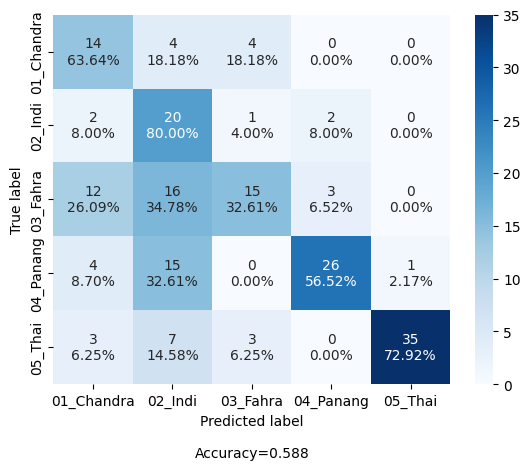

In [24]:
import seaborn as sns
from scripts.cf_matrix import make_confusion_matrix

m = results.confusion_matrix()
# sns.heatmap(m, annot=True,xticklabels=classes, yticklabels=classes, fmt="d")
make_confusion_matrix(m, categories=classes)

In [25]:
session = fo.launch_app(ds_zoo_elephants, auto=False)
session.open_tab()

Session launched. Run `session.show()` to open the App in a cell output.


<IPython.core.display.Javascript object>

In [ ]:
from fiftyone import ViewField as F

session.view = (
    ds_zoo_elephants
    # .match_tags("validation")
    .match(F("zoo_identity.label") != F("ground_truth.label"))
    # .sort_by("uniqueness", reverse=True)
)